In [1]:
# 🤖 Importación de librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import streamlit as st
import holidays

In [2]:
# Definir paths relativos desde la carpeta notebooks
ventas_path = '../data/raw/entrenamiento/ventas.csv'
competencia_path = '../data/raw/entrenamiento/competencia.csv'

# Cargar los datos en dataframes
ventas_df = pd.read_csv(ventas_path)
competencia_df = pd.read_csv(competencia_path)

# Mostrar paths y dataframes
print('ventas_path:', ventas_path)
print('competencia_path:', competencia_path)
print('ventas_df:')
print(ventas_df.head())
print('competencia_df:')
print(competencia_df.head())

ventas_path: ../data/raw/entrenamiento/ventas.csv
competencia_path: ../data/raw/entrenamiento/competencia.csv
ventas_df:
        fecha producto_id                            nombre categoria  \
0  2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1  2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2  2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3  2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4  2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  in

In [3]:
# 🤖 Informe de calidad de datos para ventas_df (versión mejorada y más clara)
import pandas as pd
from IPython.display import display

# Crear DataFrame resumen de calidad
resumen = pd.DataFrame({
    'Tipo de variable': ventas_df.dtypes,
    'Tiene nulos': ventas_df.isnull().any(),
    '% Nulos': (ventas_df.isnull().mean() * 100).round(2)
})
resumen['Tiene nulos'] = resumen['Tiene nulos'].map({True: 'Sí', False: 'No'})

# Mostrar tabla resumen
print('===== RESUMEN DE CALIDAD DE DATOS =====')
display(resumen)

# Mostrar filas duplicadas
duplicados = ventas_df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

# Estadísticos descriptivos numéricos
print('\n--- Estadísticos descriptivos numéricos ---')
display(ventas_df.describe())

# Estadísticos para variables categóricas
cat_cols = ventas_df.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    print('\n--- Estadísticos para variables categóricas ---')
    for col in cat_cols:
        print(f"\n{col}:")
        print(ventas_df[col].value_counts())
else:
    print('\nNo hay variables categóricas.')

===== RESUMEN DE CALIDAD DE DATOS =====


,Tipo de variable,Tiene nulos,% Nulos
fecha,object,No,0.0
producto_id,object,No,0.0
nombre,object,No,0.0
categoria,object,No,0.0
subcategoria,object,No,0.0
precio_base,int64,No,0.0
es_estrella,bool,No,0.0
unidades_vendidas,int64,No,0.0
precio_venta,float64,No,0.0
ingresos,float64,No,0.0


Filas duplicadas: 0

--- Estadísticos descriptivos numéricos ---


,precio_base,unidades_vendidas,precio_venta,ingresos
count,3552.000000,3552.00000,3552.000000,3552.000000
mean,123.125000,4.87866,121.816546,605.972323
std,165.576753,6.31102,164.017963,1079.071192
min,20.000000,1.00000,19.000000,19.460000
25%,48.750000,2.00000,47.212500,131.535000
50%,72.500000,3.00000,71.810000,216.570000
75%,118.750000,5.00000,118.220000,639.637500
max,830.000000,85.00000,854.220000,14508.400000



--- Estadísticos para variables categóricas ---

fecha:
fecha
2021-10-25    24
2021-10-26    24
2021-10-27    24
2021-10-28    24
2021-10-29    24
              ..
2024-11-26    24
2024-11-27    24
2024-11-28    24
2024-11-29    24
2024-11-30    24
Name: count, Length: 148, dtype: int64

producto_id:
producto_id
PROD_001    148
PROD_002    148
PROD_003    148
PROD_004    148
PROD_005    148
PROD_006    148
PROD_007    148
PROD_008    148
PROD_009    148
PROD_010    148
PROD_011    148
PROD_012    148
PROD_013    148
PROD_014    148
PROD_015    148
PROD_016    148
PROD_017    148
PROD_018    148
PROD_019    148
PROD_020    148
PROD_021    148
PROD_022    148
PROD_023    148
PROD_024    148
Name: count, dtype: int64

nombre:
nombre
Nike Air Zoom Pegasus 40            148
Adidas Ultraboost 23                148
Asics Gel Nimbus 25                 148
New Balance Fresh Foam X 1080v12    148
Nike Dri-FIT Miler                  148
Adidas Own The Run Jacket           148
Puma Velocity Nitro

In [4]:
# Convertir la columna 'fecha' a tipo datetime si no lo está
if not pd.api.types.is_datetime64_any_dtype(ventas_df['fecha']):
    ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'])
    print("Columna 'fecha' convertida a datetime.")
else:
    print("Columna 'fecha' ya es tipo datetime.")

Columna 'fecha' convertida a datetime.


In [5]:
# 🤖 Informe de calidad de datos para competencia_df (versión clara)
import pandas as pd
from IPython.display import display

# Convertir la columna 'fecha' a datetime si no lo está
def convertir_fecha(df):
    if 'fecha' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['fecha']):
        df['fecha'] = pd.to_datetime(df['fecha'])
        print("Columna 'fecha' convertida a datetime.")
    else:
        print("Columna 'fecha' ya es tipo datetime o no existe.")

convertir_fecha(competencia_df)

# Crear DataFrame resumen de calidad
resumen_comp = pd.DataFrame({
    'Tipo de variable': competencia_df.dtypes,
    'Tiene nulos': competencia_df.isnull().any(),
    '% Nulos': (competencia_df.isnull().mean() * 100).round(2)
})
resumen_comp['Tiene nulos'] = resumen_comp['Tiene nulos'].map({True: 'Sí', False: 'No'})

# Mostrar tabla resumen
print('===== RESUMEN DE CALIDAD DE DATOS (competencia_df) =====')
display(resumen_comp)

# Mostrar filas duplicadas
duplicados_comp = competencia_df.duplicated().sum()
print(f"Filas duplicadas: {duplicados_comp}")

# Estadísticos descriptivos numéricos
print('\n--- Estadísticos descriptivos numéricos ---')
display(competencia_df.describe())

# Estadísticos para variables categóricas
cat_cols_comp = competencia_df.select_dtypes(include=['object', 'category']).columns
if len(cat_cols_comp) > 0:
    print('\n--- Estadísticos para variables categóricas ---')
    for col in cat_cols_comp:
        print(f"\n{col}:")
        print(competencia_df[col].value_counts())
else:
    print('\nNo hay variables categóricas.')

Columna 'fecha' convertida a datetime.
===== RESUMEN DE CALIDAD DE DATOS (competencia_df) =====


,Tipo de variable,Tiene nulos,% Nulos
fecha,datetime64[ns],No,0.0
producto_id,object,No,0.0
Amazon,float64,No,0.0
Decathlon,float64,No,0.0
Deporvillage,float64,No,0.0


Filas duplicadas: 0

--- Estadísticos descriptivos numéricos ---


,fecha,Amazon,Decathlon,Deporvillage
count,3552,3552.000000,3552.000000,3552.000000
mean,2023-05-13 18:00:00.000000256,118.623407,111.412182,118.894628
min,2021-10-25 00:00:00,16.850000,15.450000,16.770000
25%,2022-08-03 18:00:00,47.117500,43.285000,47.310000
50%,2023-05-13 12:00:00,73.180000,66.285000,72.700000
75%,2024-02-20 12:00:00,114.342500,111.172500,114.985000
max,2024-11-30 00:00:00,858.350000,867.337500,932.325000
std,NaN,156.095628,148.508132,160.216448



--- Estadísticos para variables categóricas ---

producto_id:
producto_id
PROD_001    148
PROD_002    148
PROD_003    148
PROD_004    148
PROD_005    148
PROD_006    148
PROD_007    148
PROD_008    148
PROD_009    148
PROD_010    148
PROD_011    148
PROD_012    148
PROD_013    148
PROD_014    148
PROD_015    148
PROD_016    148
PROD_017    148
PROD_018    148
PROD_019    148
PROD_020    148
PROD_021    148
PROD_022    148
PROD_023    148
PROD_024    148
Name: count, dtype: int64


In [62]:
# 🤖 Integración de ventas_df y competencia_df en un nuevo DataFrame df usando 'fecha' y 'producto_id' como claves

df = pd.merge(
    ventas_df,
    competencia_df,
    on=['fecha', 'producto_id'],
    how='inner',  # Solo filas con coincidencia en ambas tablas
    suffixes=('_ventas', '_competencia')
)

print('Shape del DataFrame integrado:', df.shape)
display(df.head())

Shape del DataFrame integrado: (3552, 15)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,año,dia_semana,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,2021,Monday,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,2021,Monday,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,2021,Monday,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,2021,Monday,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,2021,Monday,37.71,33.60,33.07


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
 10  año                3552 non-null   int32         
 11  dia_semana         3552 non-null   object        
 12  Amazon             3552 non-null   float64       
 13  Decathlon          3552 non-null   float64       
 14  Deporvil

In [8]:
competencia_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[ns]
 1   producto_id   3552 non-null   object        
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 138.9+ KB


## Análisis exploratorio de ventas: líneas temporales por año y Black Fridays

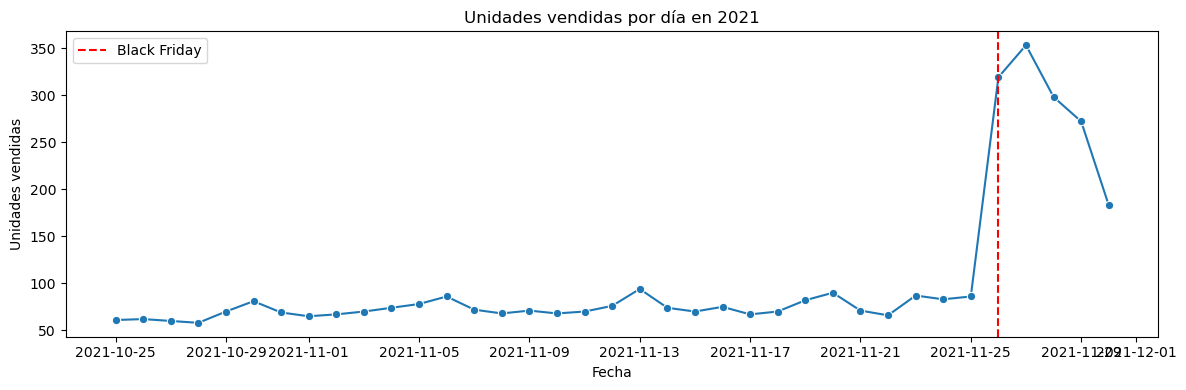

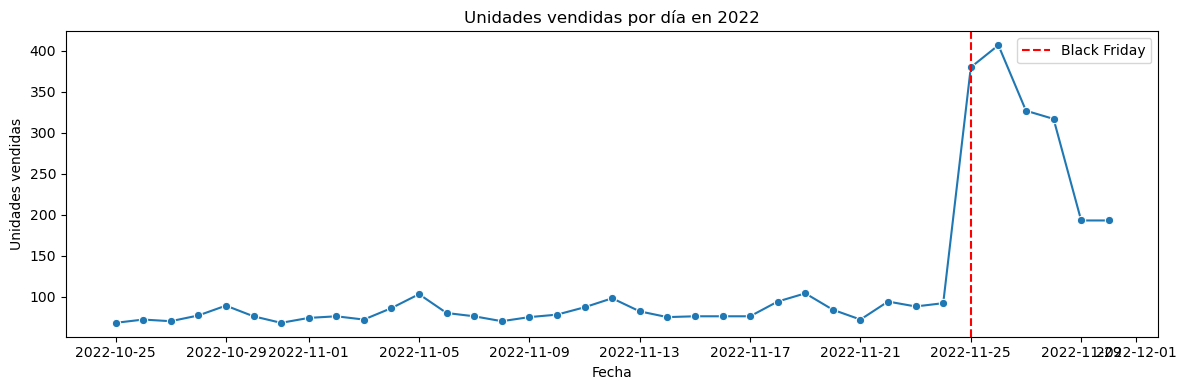

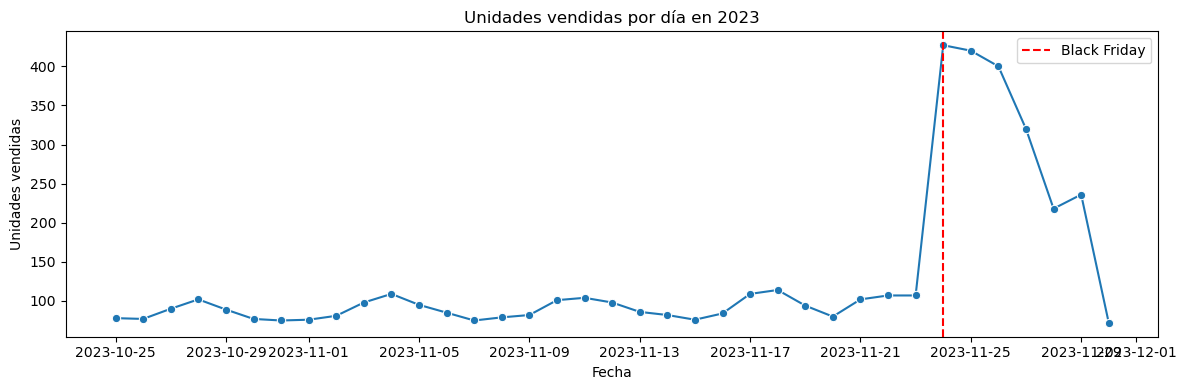

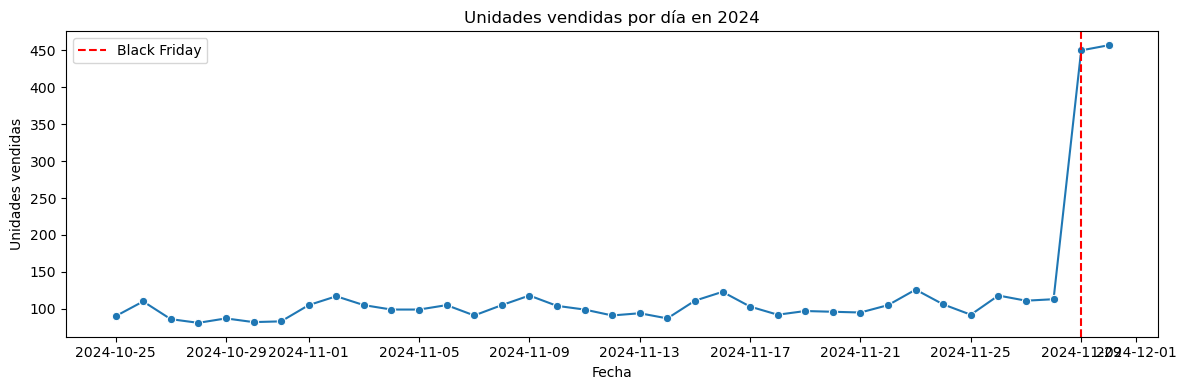

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

# Aseguramos que la columna fecha es datetime
ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'])

# Extraemos el año
ventas_df['año'] = ventas_df['fecha'].dt.year

# Calculamos los días de Black Friday (último viernes de noviembre)
def get_black_fridays(years):
    bf_days = []
    for y in years:
        nov = pd.date_range(start=f'{y}-11-01', end=f'{y}-11-30', freq='D')
        fridays = nov[nov.weekday == 4]
        bf_days.append(fridays[-1])
    return bf_days

years = ventas_df['año'].unique()
black_fridays = get_black_fridays(years)

# Gráficos de líneas por año
for y in sorted(years):
    plt.figure(figsize=(12,4))
    data = ventas_df[ventas_df['año'] == y].groupby('fecha')['unidades_vendidas'].sum()
    sns.lineplot(x=data.index, y=data.values, marker='o')
    # Marcar Black Friday
    bf = [d for d in black_fridays if d.year == y]
    for bfd in bf:
        plt.axvline(bfd, color='red', linestyle='--', label='Black Friday')
    plt.title(f'Unidades vendidas por día en {y}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Unidades vendidas por día de la semana

C:\Users\Usuario\AppData\Local\Temp\ipykernel_23936\586993892.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


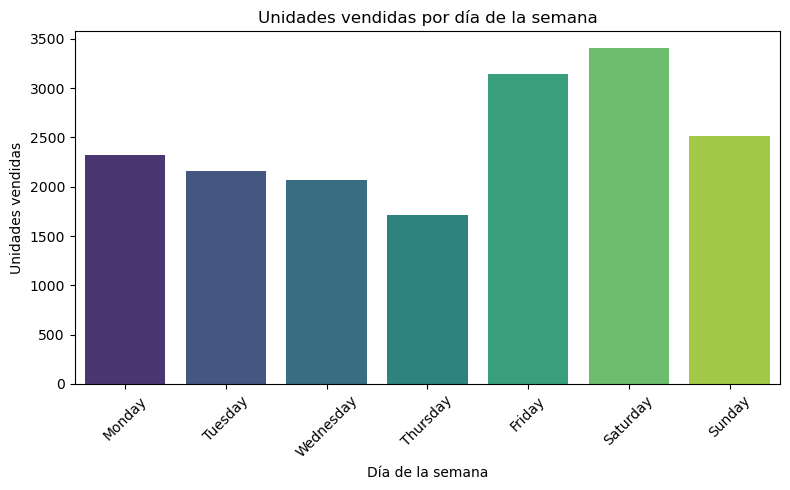

In [16]:
# Agregar columna de día de la semana
ventas_df['dia_semana'] = ventas_df['fecha'].dt.day_name()
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(8,5))
sns.barplot(
    x='dia_semana',
    y='unidades_vendidas',
    data=ventas_df.groupby('dia_semana', as_index=False)['unidades_vendidas'].sum(),
    order=orden_dias,
    palette='viridis'
)
plt.title('Unidades vendidas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Unidades vendidas por categoría

C:\Users\Usuario\AppData\Local\Temp\ipykernel_23936\1224660412.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


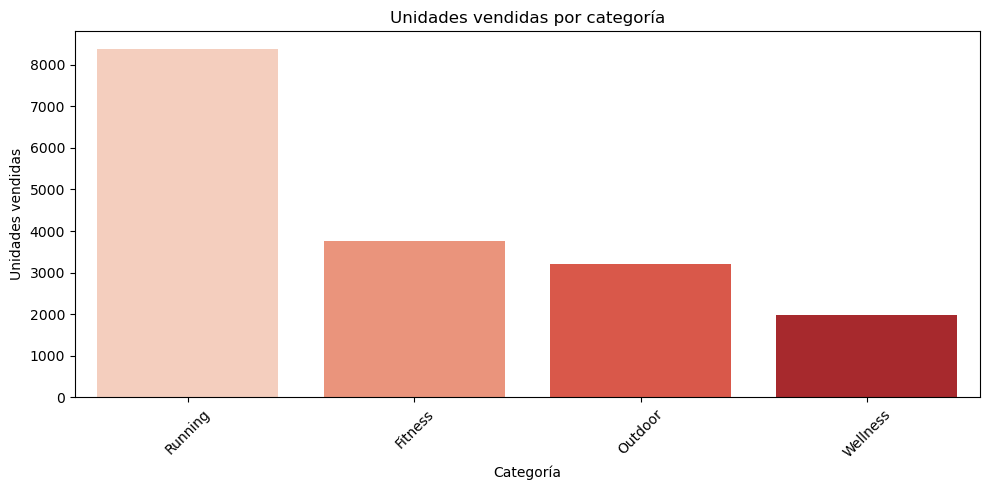

In [23]:
plt.figure(figsize=(10,5))
data_cat = ventas_df.groupby('categoria', as_index=False)['unidades_vendidas'].sum().sort_values('unidades_vendidas', ascending=False)
ax = sns.barplot(
    x='categoria',
    y='unidades_vendidas',
    data=data_cat,
    palette='Reds'
)
plt.title('Unidades vendidas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Unidades vendidas por subcategoría

C:\Users\Usuario\AppData\Local\Temp\ipykernel_23936\1181869099.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


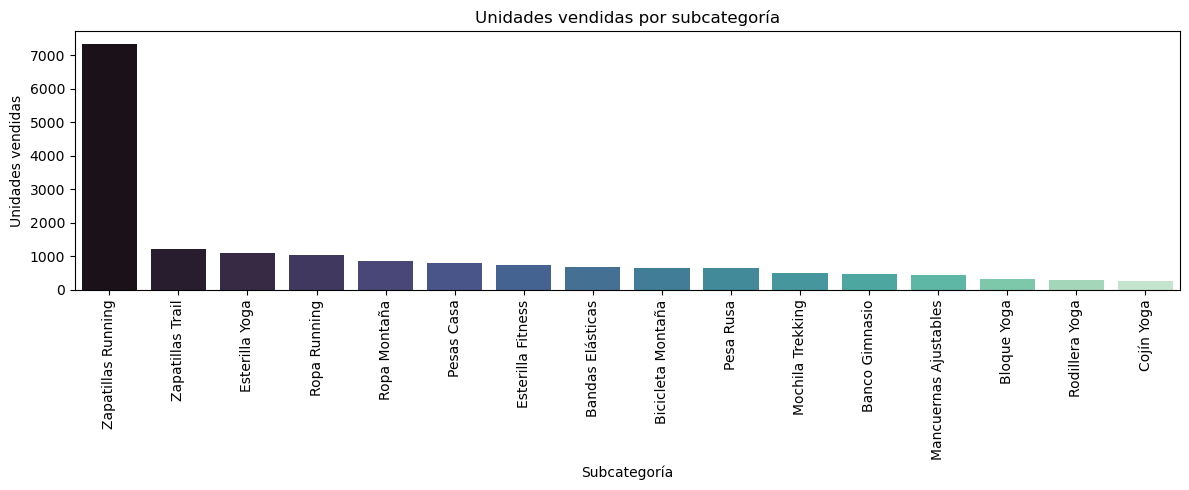

In [24]:
plt.figure(figsize=(12,5))
sns.barplot(
    x='subcategoria',
    y='unidades_vendidas',
    data=ventas_df.groupby('subcategoria', as_index=False)['unidades_vendidas'].sum().sort_values('unidades_vendidas', ascending=False),
    palette='mako'
)
plt.title('Unidades vendidas por subcategoría')
plt.xlabel('Subcategoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Unidades vendidas por top productos

C:\Users\Usuario\AppData\Local\Temp\ipykernel_23936\2223387510.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


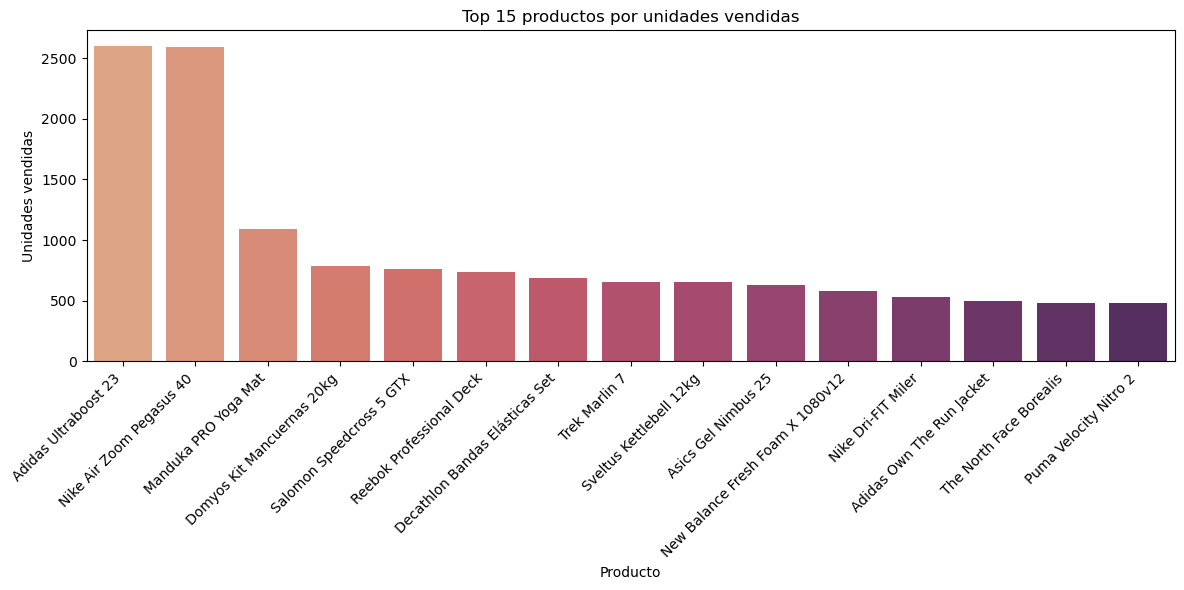

In [26]:
top_n = 15
top_productos = ventas_df.groupby(['producto_id', 'nombre'], as_index=False)['unidades_vendidas'].sum()
top_productos = top_productos.sort_values('unidades_vendidas', ascending=False).head(top_n)

plt.figure(figsize=(12,6))
sns.barplot(
    x='nombre',
    y='unidades_vendidas',
    data=top_productos,
    palette='flare',
    order=top_productos.sort_values('unidades_vendidas', ascending=False)['nombre']
)
plt.title(f'Top {top_n} productos por unidades vendidas')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Análisis de densidad de precios: nuestros vs Amazon

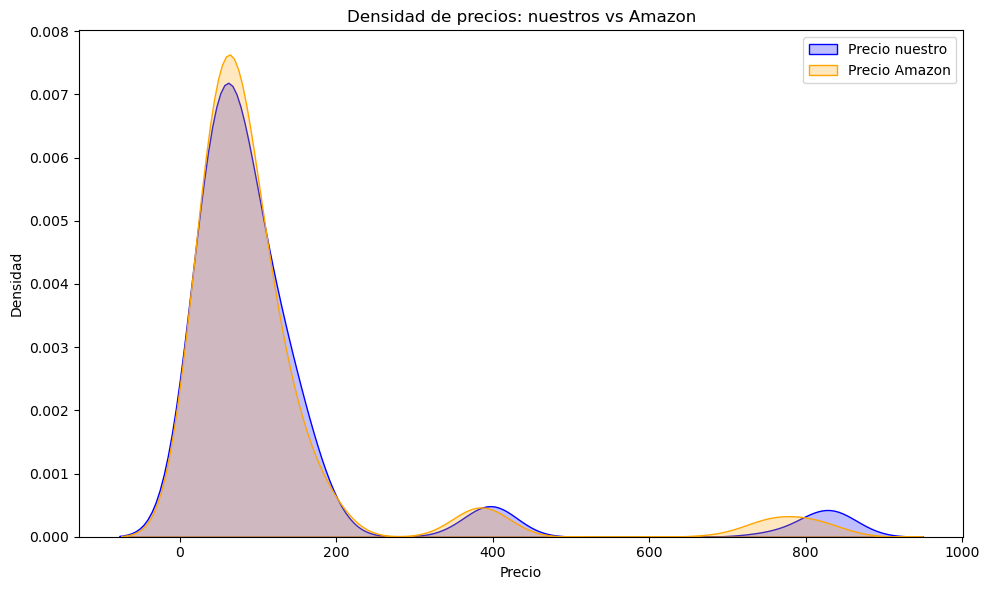

In [27]:
# Unimos precios nuestros y de Amazon por producto y fecha
precios = pd.merge(
    ventas_df[['fecha', 'producto_id', 'precio_venta']],
    competencia_df[['fecha', 'producto_id', 'Amazon']],
    on=['fecha', 'producto_id'],
    how='inner'
)

plt.figure(figsize=(10,6))
sns.kdeplot(precios['precio_venta'], label='Precio nuestro', fill=True, color='blue')
sns.kdeplot(precios['Amazon'], label='Precio Amazon', fill=True, color='orange')
plt.title('Densidad de precios: nuestros vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

## Creación de variables temporales y de calendario para df

In [63]:
import holidays

# Variables temporales y de calendario para df

df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_mes'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['nombre_dia_semana'] = df['fecha'].dt.day_name()
df['semana_año'] = df['fecha'].dt.isocalendar().week
df['es_fin_de_semana'] = df['dia_semana'].isin([5,6])

# Festivos en España
years_df = df['año'].unique()
festivos_es = holidays.country_holidays('ES', years=years_df)
df['es_festivo'] = df['fecha'].isin(festivos_es)

# Black Friday (último viernes de noviembre)
def es_black_friday(fecha):
    if fecha.month == 11 and fecha.weekday() == 4:
        ult_viernes = max([d for d in pd.date_range(start=fecha.replace(day=1), end=fecha.replace(day=30)) if d.weekday() == 4])
        return fecha == ult_viernes
    return False
df['es_Black_Friday'] = df['fecha'].apply(es_black_friday)

# Cyber Monday (primer lunes después de Black Friday)
def es_cyber_monday(fecha):
    if fecha.month == 11 or fecha.month == 12:
        year = fecha.year
        nov = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
        fridays = nov[nov.weekday == 4]
        black_friday = fridays[-1]
        cyber_monday = black_friday + pd.Timedelta(days=3)
        return fecha == cyber_monday
    return False
df['es_Cyber_Monday'] = df['fecha'].apply(es_cyber_monday)

# Variables adicionales interesantes
df['inicio_mes'] = df['fecha'].dt.is_month_start
df['fin_mes'] = df['fecha'].dt.is_month_end
df['trimestre'] = df['fecha'].dt.quarter
df['es_verano'] = df['mes'].isin([6,7,8,9])
df['es_navidad'] = df['fecha'].dt.month.isin([12]) & (df['fecha'].dt.day >= 15)

df.head()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_23936\1397394780.py:16: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['es_festivo'] = df['fecha'].isin(festivos_es)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,semana_año,es_fin_de_semana,es_festivo,es_Black_Friday,es_Cyber_Monday,inicio_mes,fin_mes,trimestre,es_verano,es_navidad
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,43,False,False,False,False,False,False,4,False,False
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,43,False,False,False,False,False,False,4,False,False
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,43,False,False,False,False,False,False,4,False,False
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,43,False,False,False,False,False,False,4,False,False
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,43,False,False,False,False,False,False,4,False,False


## Creación de lags 1-7 y media móvil 7 días de unidades vendidas (por año, eliminando nulos)

In [64]:
# Crear lags de unidades_vendidas (1 a 7) y media móvil de 7 días, por producto y año
# Crear lags de unidades_vendidas (1 a 7) y media móvil de 7 días, solo agrupando por año
lags = range(1, 8)
for lag in lags:
    df[f'unidades_vendidas_lag{lag}'] = (
        df.sort_values(['año', 'fecha'])
          .groupby(['año'])['unidades_vendidas']
          .shift(lag)
    )

# Media móvil de 7 días (incluye el día actual y los 6 anteriores), solo por año
df['unidades_vendidas_mm7'] = (
    df.sort_values(['año', 'fecha'])
      .groupby(['año'])['unidades_vendidas']
      .transform(lambda x: x.rolling(window=7, min_periods=7).mean())
)

# Eliminar registros con nulos en los nuevos lags o media móvil
cols_lag_mm = [f'unidades_vendidas_lag{lag}' for lag in lags] + ['unidades_vendidas_mm7']
df = df.dropna(subset=cols_lag_mm).reset_index(drop=True)
print('Shape del DataFrame integrado:', df.shape)

Shape del DataFrame integrado: (3524, 36)


In [61]:
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,Decathlon,Deporvillage,unidades_vendidas_lag1,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_mm7
0,2021-10-26,PROD_012,Domyos Kit Mancuernas 20kg,Fitness,Pesas Casa,55,False,4,55.55,222.20,...,50.32,55.73,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.142857
1,2021-10-26,PROD_013,Decathlon Bandas Elásticas Set,Fitness,Bandas Elásticas,25,False,2,24.46,48.92,...,22.89,26.70,4.0,2.0,1.0,2.0,2.0,2.0,2.0,2.142857
2,2021-10-26,PROD_014,Sveltus Kettlebell 12kg,Fitness,Pesa Rusa,40,False,2,40.42,80.84,...,36.83,41.61,2.0,4.0,2.0,1.0,2.0,2.0,2.0,2.142857
3,2021-10-26,PROD_015,Salomon Speedcross 5 GTX,Outdoor,Zapatillas Trail,150,True,3,154.23,462.69,...,142.60,130.50,2.0,2.0,4.0,2.0,1.0,2.0,2.0,2.285714
4,2021-10-26,PROD_016,Trek Marlin 7,Outdoor,Bicicleta Montaña,830,True,2,827.20,1654.40,...,713.33,766.45,3.0,2.0,2.0,4.0,2.0,1.0,2.0,2.285714


In [65]:
df.groupby('año').size()

año
2021    881
2022    881
2023    881
2024    881
dtype: int64

In [66]:
#Variable de descuento porcentaje
df['descuento_porcentaje'] = (df['precio_venta'] - df['precio_base']) / df['precio_base'] * 100
df[["fecha", "producto_id", "precio_venta", "precio_base", "descuento_porcentaje"]].head()

,fecha,producto_id,precio_venta,precio_base,descuento_porcentaje
0,2021-10-25,PROD_008,66.60,65,2.461538
1,2021-10-25,PROD_009,392.31,400,-1.922500
2,2021-10-25,PROD_010,174.92,175,-0.045714
3,2021-10-25,PROD_011,44.32,45,-1.511111
4,2021-10-25,PROD_012,55.05,55,0.090909


## Creación de variables de precio_competencia y ratio_precio, y eliminación de columnas de competidores

In [67]:
# Calcular precio promedio de la competencia
competidores = ['Amazon', 'Decathlon', 'Deporvillage']
df['precio_competencia'] = df[competidores].mean(axis=1)

# Calcular ratio de nuestro precio respecto a la competencia
df['ratio_precio'] = df['precio_venta'] / df['precio_competencia']

# Eliminar columnas de los competidores
df = df.drop(columns=competidores)

df[['fecha', 'producto_id', 'precio_venta', 'precio_competencia', 'ratio_precio']].head()

,fecha,producto_id,precio_venta,precio_competencia,ratio_precio
0,2021-10-25,PROD_008,66.60,64.346667,1.035019
1,2021-10-25,PROD_009,392.31,350.850000,1.118170
2,2021-10-25,PROD_010,174.92,160.156667,1.092181
3,2021-10-25,PROD_011,44.32,44.563333,0.994540
4,2021-10-25,PROD_012,55.05,53.246667,1.033868


## One Hot Encoding de nombre, categoría y subcategoría (con sufijo _h)

In [69]:
# Crear copias de las variables con sufijo _h
df['nombre_h'] = df['nombre']
df['categoria_h'] = df['categoria']
df['subcategoria_h'] = df['subcategoria']

# One Hot Encoding sobre las nuevas variables
one_hot = pd.get_dummies(df[['nombre_h', 'categoria_h', 'subcategoria_h']], prefix=['nombre_h', 'categoria_h', 'subcategoria_h'])
df = pd.concat([df, one_hot], axis=1)

df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-10-25,PROD_008,Reebok Floatride Energy 5,Running,Zapatillas Running,65,False,2,66.60,133.20,...,False,False,False,False,False,False,False,False,True,False
1,2021-10-25,PROD_009,Bowflex SelectTech 552,Fitness,Mancuernas Ajustables,400,True,2,392.31,784.62,...,False,True,False,False,False,False,False,False,False,False
2,2021-10-25,PROD_010,Domyos BM900,Fitness,Banco Gimnasio,175,True,2,174.92,349.84,...,False,False,False,False,False,False,False,False,False,False
3,2021-10-25,PROD_011,Reebok Professional Deck,Fitness,Esterilla Fitness,45,False,3,44.32,132.96,...,False,False,False,False,False,False,False,False,False,False
4,2021-10-25,PROD_012,Domyos Kit Mancuernas 20kg,Fitness,Pesas Casa,55,False,3,55.05,165.15,...,False,False,False,False,True,False,False,False,False,False


In [73]:
# Guardar el DataFrame df en la carpeta data/processed
df.to_csv('../data/processed/df.csv', index=False)
print('Archivo guardado en data/processed/df.csv')

Archivo guardado en data/processed/df.csv


In [86]:
# Dividir df en train_df (2021-2023) y validation_df (2024)
train_df = df[df['año'].isin([2021, 2022, 2023])].copy()
validation_df = df[df['año'] == 2024].copy()

print(f'Registros en train_df: {len(train_df)}')
print(f'Registros en validation_df: {len(validation_df)}')

Registros en train_df: 2643
Registros en validation_df: 881


## Entrenamiento y validación de HistGradientBoostingRegressor con baseline naive

In [89]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Selección de variables predictoras (excluyendo fecha, ingresos y tipo object)
excluir = ['fecha', 'ingresos', 'unidades_vendidas']
# Selecciona solo columnas numéricas que no estén en la lista de exclusión
X_cols = [col for col in train_df.select_dtypes(exclude=['object', 'datetime']).columns if col not in excluir]

X_train = train_df[X_cols]
y_train = train_df['unidades_vendidas']
X_val = validation_df[X_cols]
y_val = validation_df['unidades_vendidas']

# Modelo conservador
model = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    min_samples_leaf=20,
    random_state=42
)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_val)

# Baseline naive: predice la media de train
y_pred_naive = [y_train.mean()] * len(y_val)

# Métricas
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

mae_naive = mean_absolute_error(y_val, y_pred_naive)
mse_naive = mean_squared_error(y_val, y_pred_naive)
rmse_naive = np.sqrt(mse_naive)
r2_naive = r2_score(y_val, y_pred_naive)

print('HistGradientBoostingRegressor:')
print(f'MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.3f}')
print('Baseline naive:')
print(f'MAE: {mae_naive:.2f} | RMSE: {rmse_naive:.2f} | R2: {r2_naive:.3f}')

HistGradientBoostingRegressor:
MAE: 0.67 | RMSE: 1.50 | R2: 0.943
Baseline naive:
MAE: 3.34 | RMSE: 6.25 | R2: -0.000


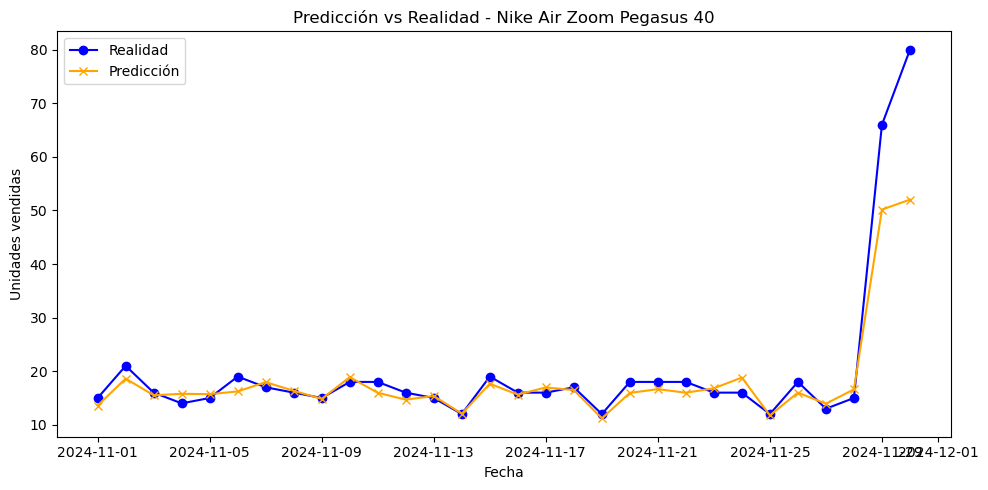

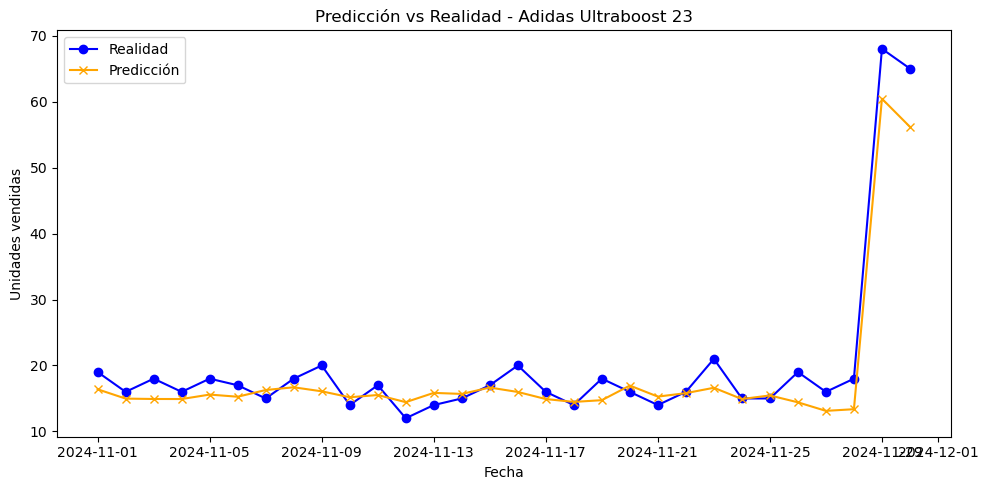

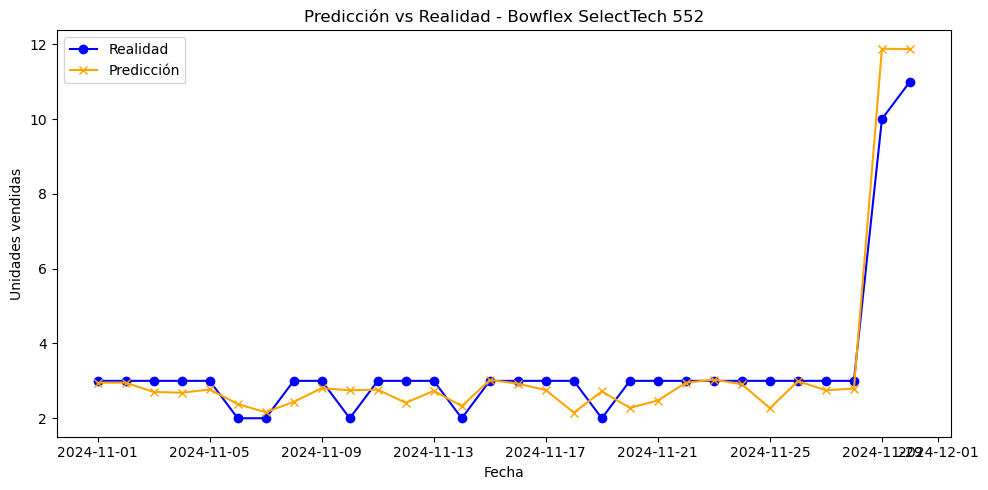

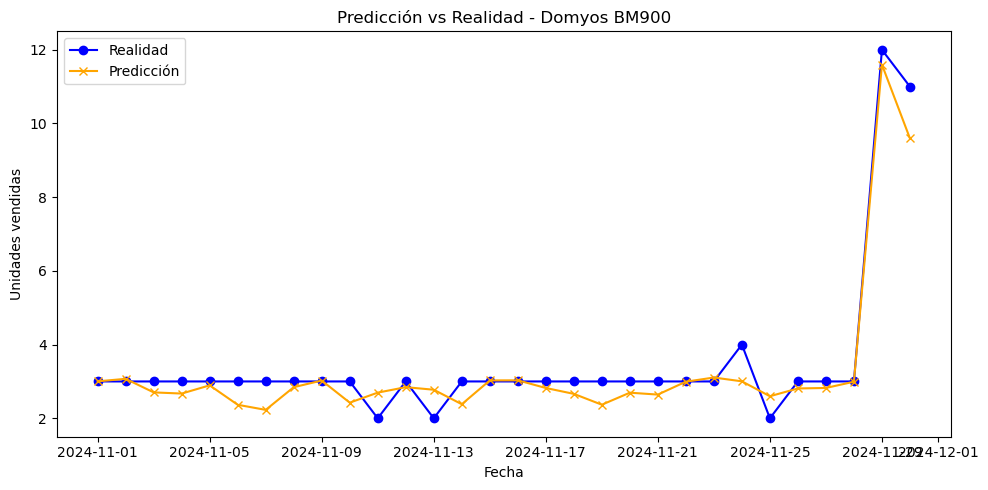

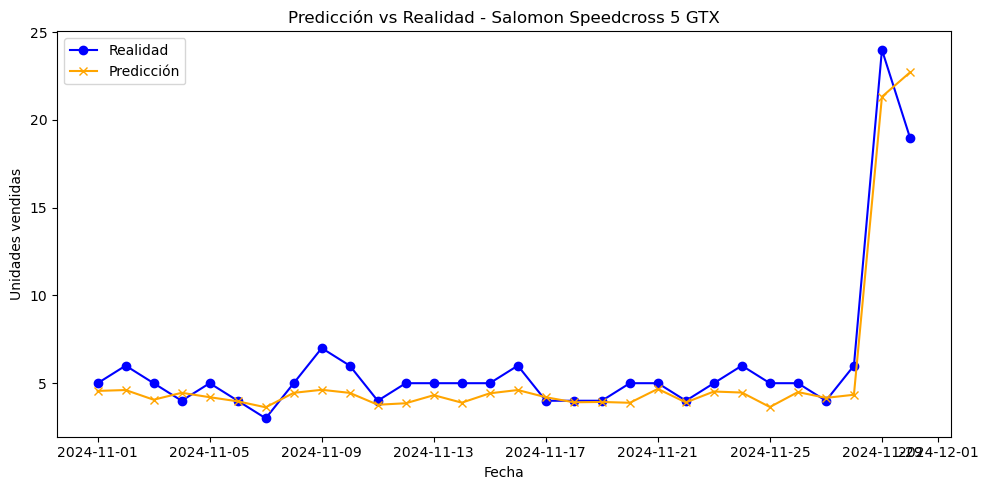

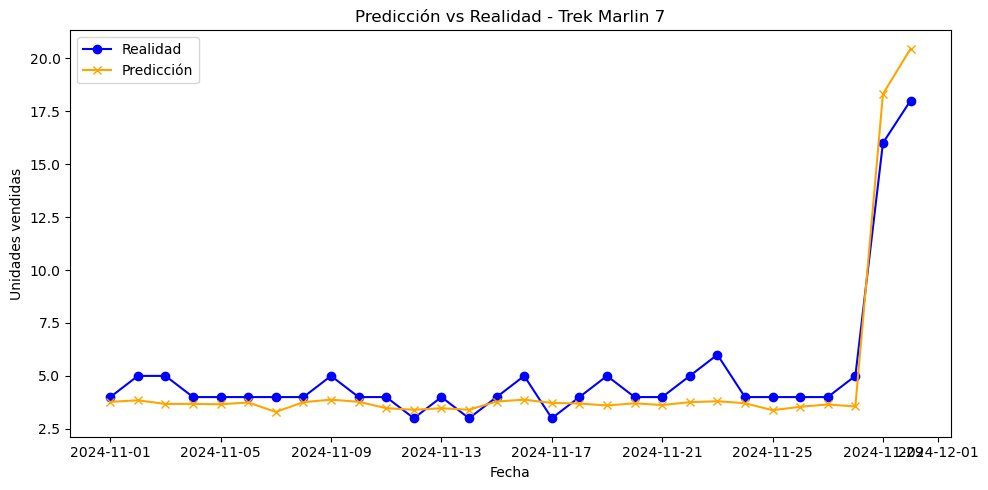

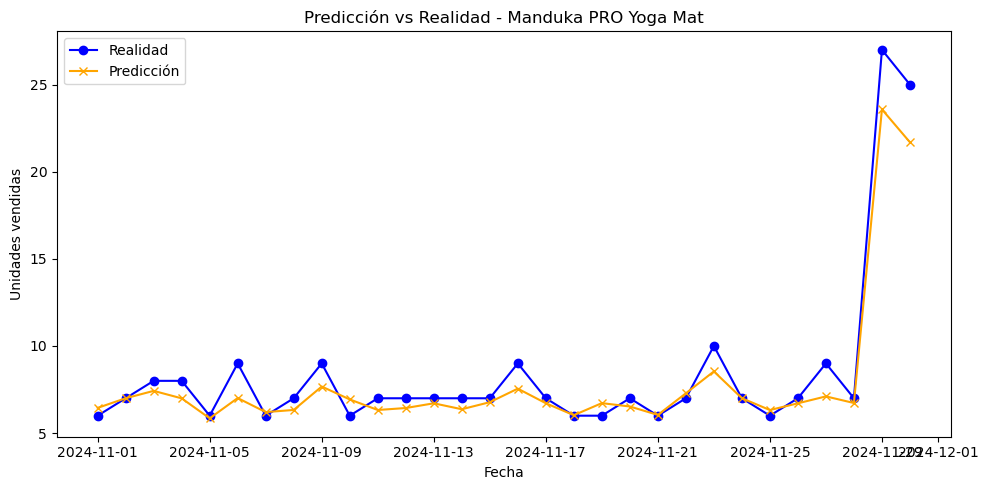

In [90]:
# 🤖 Predicción y visualización para los 7 productos estrella en noviembre 2024
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar noviembre 2024
nov_2024 = df[(df['año'] == 2024) & (df['mes'] == 11)]

# Filtrar productos estrella
productos_estrella = nov_2024[nov_2024['es_estrella'] == True]['producto_id'].unique()

# Obtener nombres de productos estrella
nombres_estrella = nov_2024[nov_2024['es_estrella'] == True].drop_duplicates('producto_id')[['producto_id', 'nombre']]

# Selección de variables predictoras (igual que en el modelo)
excluir = ['fecha', 'ingresos', 'unidades_vendidas']
X_cols = [col for col in nov_2024.select_dtypes(exclude=['object', 'datetime']).columns if col not in excluir]

# Generar predicciones para cada producto estrella y graficar
for pid in productos_estrella:
    nombre = nombres_estrella[nombres_estrella['producto_id'] == pid]['nombre'].values[0]
    datos_prod = nov_2024[nov_2024['producto_id'] == pid].copy()
    X_prod = datos_prod[X_cols]
    y_real = datos_prod['unidades_vendidas']
    fechas = datos_prod['fecha']
    y_pred = model.predict(X_prod)

    plt.figure(figsize=(10,5))
    plt.plot(fechas, y_real, label='Realidad', marker='o', color='blue')
    plt.plot(fechas, y_pred, label='Predicción', marker='x', color='orange')
    plt.title(f'Predicción vs Realidad - {nombre}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [91]:
# 🤖 Cálculo del MAE para cada producto estrella en noviembre 2024
from sklearn.metrics import mean_absolute_error

mae_por_producto = {}
for pid in productos_estrella:
    nombre = nombres_estrella[nombres_estrella['producto_id'] == pid]['nombre'].values[0]
    datos_prod = nov_2024[nov_2024['producto_id'] == pid].copy()
    X_prod = datos_prod[X_cols]
    y_real = datos_prod['unidades_vendidas']
    y_pred = model.predict(X_prod)
    mae = mean_absolute_error(y_real, y_pred)
    mae_por_producto[nombre] = mae
    print(f"Producto: {nombre} | MAE: {mae:.2f}")

Producto: Nike Air Zoom Pegasus 40 | MAE: 2.58
Producto: Adidas Ultraboost 23 | MAE: 2.37
Producto: Bowflex SelectTech 552 | MAE: 0.39
Producto: Domyos BM900 | MAE: 0.37
Producto: Salomon Speedcross 5 GTX | MAE: 0.94
Producto: Trek Marlin 7 | MAE: 0.78
Producto: Manduka PRO Yoga Mat | MAE: 0.80


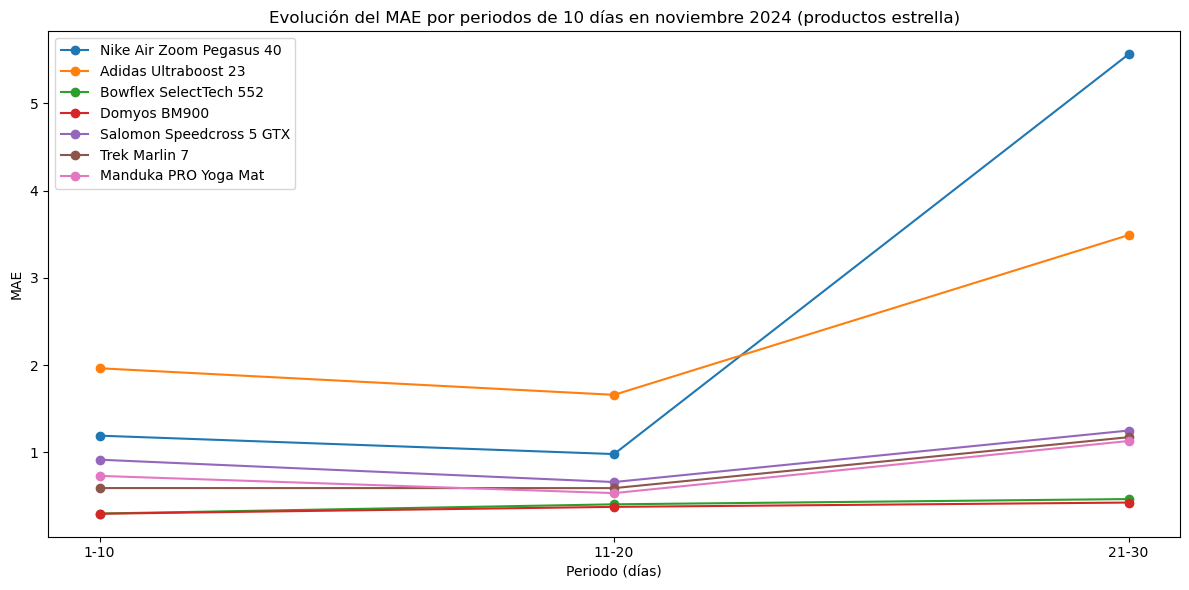

,producto,periodo,mae,rmse,r2
0,Nike Air Zoom Pegasus 40,1-10,1.191331,1.453652,0.501627
1,Nike Air Zoom Pegasus 40,11-20,0.980491,1.180036,0.726427
2,Nike Air Zoom Pegasus 40,21-30,5.560599,10.272629,0.803839
3,Adidas Ultraboost 23,1-10,1.963452,2.178380,-0.535709
4,Adidas Ultraboost 23,11-20,1.659077,2.030030,0.121317
5,Adidas Ultraboost 23,21-30,3.489087,4.549867,0.948300
6,Bowflex SelectTech 552,1-10,0.298896,0.364809,0.366259
7,Bowflex SelectTech 552,11-20,0.404691,0.490066,-0.501027
8,Bowflex SelectTech 552,21-30,0.464959,0.722569,0.942309
9,Domyos BM900,1-10,0.296619,0.395593,0.000000


In [92]:
# 🤖 Análisis de la degradación del error en noviembre 2024 por periodos de 10 días para productos estrella
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Definir los periodos
periodos = [(1,10), (11,20), (21,30)]
metricas_periodo = []

for pid in productos_estrella:
    nombre = nombres_estrella[nombres_estrella['producto_id'] == pid]['nombre'].values[0]
    datos_prod = nov_2024[nov_2024['producto_id'] == pid].copy()
    X_prod = datos_prod[X_cols]
    y_real = datos_prod['unidades_vendidas']
    fechas = datos_prod['fecha']
    y_pred = model.predict(X_prod)
    
    for i, (ini, fin) in enumerate(periodos):
        mask = (datos_prod['dia_mes'] >= ini) & (datos_prod['dia_mes'] <= fin)
        y_real_p = y_real[mask]
        y_pred_p = y_pred[mask]
        fechas_p = fechas[mask]
        if len(y_real_p) > 0:
            mae = mean_absolute_error(y_real_p, y_pred_p)
            rmse = np.sqrt(mean_squared_error(y_real_p, y_pred_p))
            r2 = r2_score(y_real_p, y_pred_p)
            metricas_periodo.append({'producto': nombre, 'periodo': f'{ini}-{fin}', 'mae': mae, 'rmse': rmse, 'r2': r2})

# Convertir a DataFrame para graficar
metricas_df = pd.DataFrame(metricas_periodo)

# Graficar la evolución del MAE por periodo para cada producto estrella
plt.figure(figsize=(12,6))
for nombre in metricas_df['producto'].unique():
    datos = metricas_df[metricas_df['producto'] == nombre]
    plt.plot(datos['periodo'], datos['mae'], marker='o', label=nombre)
plt.title('Evolución del MAE por periodos de 10 días en noviembre 2024 (productos estrella)')
plt.xlabel('Periodo (días)')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()

# Mostrar tabla de métricas
display(metricas_df)